https://dlo.mijnhva.nl/d2l/le/content/691830/viewContent/2753548/View

# Methoden en Technieken -- Blok 2

## Datapunt 2a,

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen**, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld**
machine learning, **deep learning**, kennisrepresentatie, computer vision en **natural language
processing**.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch
proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
explainability, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)


In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch" # Has to be set before importing keras otherwise it can't be set anymore

import random
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
import tensorflow as tf

import pickle
import numpy as np

import string
import re, json
import math

random.seed(67)
np.random.seed(67)
tf.random.set_seed(67)


import seaborn as sns
from collections import Counter
from lexical_diversity import lex_div as ld
from itertools import chain
import sentencepiece as spm
from pathlib import Path
from sacrebleu.metrics import CHRF
import pandas as pd

c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\lexical_diversity\lex_div.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
DATA_PATH = "nld-eng/nld.txt"
MODEL_DIR = "models"


## De opdracht

In de slides van les 3 staat hoe een Engels - Nederlands vertaalmodel gemaakt wordt met een transformer-encoder en -decoder.

### Deel 1
#### Deel 1a
Maak dit model na en fit dit model.

#### Load data

In [34]:
with open(DATA_PATH, "r", encoding="utf8") as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []
for line in lines:
    english, dutch, rest = line.split("\t")
    dutch = "[start] " + dutch + " [end]"
    text_pairs.append((english, dutch))

random.shuffle(text_pairs)

print("\nTotal number of sentence pairs:", len(text_pairs))
print("Example pair:", random.choice(text_pairs))


Total number of sentence pairs: 83864
Example pair: ('The success of her novel made her rich.', '[start] Het succes van haar roman heeft haar rijk gemaakt. [end]')


#### Split dat

In [4]:
val_samples = int(0.15 * len(text_pairs))
train_samples = len(text_pairs) - 2 * val_samples

train_pairs = text_pairs[:train_samples]
val_pairs = text_pairs[train_samples : train_samples + val_samples]
test_pairs = text_pairs[train_samples + val_samples :]

print(f"Train pairs: {len(train_pairs)}")
print(f"Val   pairs: {len(val_pairs)}")
print(f"Test  pairs: {len(test_pairs)}")

Train pairs: 58706
Val   pairs: 12579
Test  pairs: 12579


#### Data exploration

In [5]:
print(random.choice(train_pairs))

def sentence_lengths(pairs):
    en_lengths = [len(p[0].split()) for p in pairs]
    nl_lengths = [len(p[1].split()) for p in pairs]
    return en_lengths, nl_lengths

train_en_lengths, train_nl_lengths = sentence_lengths(train_pairs)
print("\nAverage English length in train:", sum(train_en_lengths) / len(train_en_lengths))
print("Average Dutch length in train  :", sum(train_nl_lengths) / len(train_nl_lengths))

('There was a bus schedule on the wall.', '[start] Er hing een busdienstregeling op de muur. [end]')

Average English length in train: 5.721595748305114
Average Dutch length in train  : 7.964688447518141


In [6]:
# Duplicate source sentences: show a few conflicts and total count
from collections import defaultdict
import itertools

pairs = []
if 'train_pairs' in globals() and isinstance(train_pairs, list):
    pairs += train_pairs
if 'val_pairs' in globals() and isinstance(val_pairs, list):
    pairs += val_pairs

src_to_tgts = defaultdict(set)
for src, tgt in pairs:
    s, t = src.strip(), tgt.strip()
    if s and t:
        src_to_tgts[s].add(t)

conflicts = {s: list(ts) for s, ts in src_to_tgts.items() if len(ts) > 1}
print(f"Conflicting source sentences: {len(conflicts)}")

for s, ts in itertools.islice(conflicts.items(), 5):
    print("\nSource:", s)
    for t in ts:
        print("  -", t)


Conflicting source sentences: 8186

Source: My name is Tom.
  - [start] Ik heet Tom. [end]
  - [start] Mijn naam is Tom. [end]

Source: I'm bored.
  - [start] Ik verveel me. [end]
  - [start] Ik verveel mij. [end]

Source: She was injured in the traffic accident.
  - [start] Ze raakte gewond bij het verkeersongeval. [end]
  - [start] Zij raakte gewond bij het verkeersongeval. [end]

Source: We stopped working.
  - [start] Wij zijn gestopt met het werk. [end]
  - [start] We zijn gestopt met het werk. [end]

Source: The lecture was really boring.
  - [start] De lezing was erg saai. [end]
  - [start] De lezing was echt saai. [end]


Dutch sentences: 12579; mean=5.69; median=5.00
English sentences: 12579; mean=7.94; median=8.00


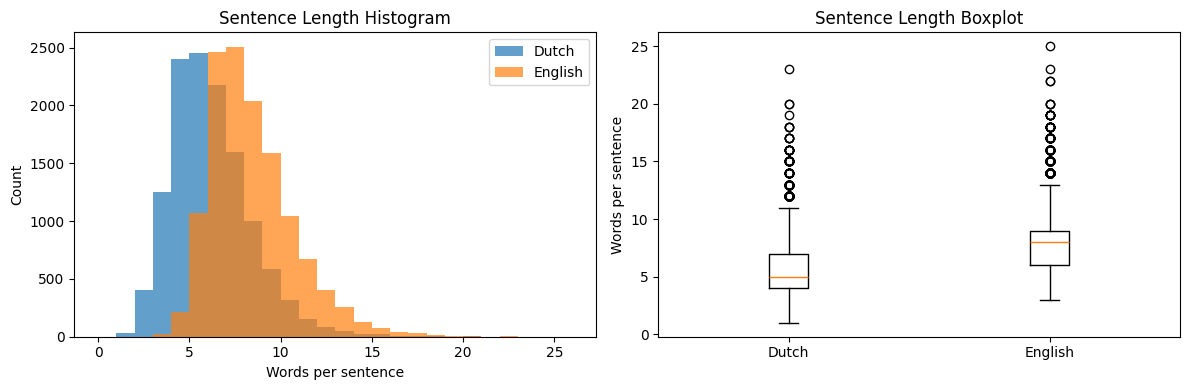

In [7]:
def sentence_lengths(texts):
    return [len(t.strip().split()) for t in texts if isinstance(t, str)]

# Collect texts safely from globals
def get_list(name):
    return globals().get(name, []) if isinstance(globals().get(name, []), list) else []

nl_texts = get_list('train_dutch_texts')
en_texts = get_list('train_english_texts')

val_pairs = get_list('val_pairs')
if val_pairs:
    nl_texts += [p[0] for p in val_pairs]
    en_texts += [p[1] for p in val_pairs]

# Compute lengths
nl_lengths = sentence_lengths(nl_texts)
en_lengths = sentence_lengths(en_texts)

print(f"Dutch sentences: {len(nl_lengths)}; mean={np.mean(nl_lengths):.2f}; median={np.median(nl_lengths):.2f}")
print(f"English sentences: {len(en_lengths)}; mean={np.mean(en_lengths):.2f}; median={np.median(en_lengths):.2f}")

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
bins = np.arange(0, max(nl_lengths + en_lengths) + 2)

axs[0].hist(nl_lengths, bins=bins, alpha=0.7, label='Dutch')
axs[0].hist(en_lengths, bins=bins, alpha=0.7, label='English')
axs[0].set_title('Sentence Length Histogram')
axs[0].set_xlabel('Words per sentence')
axs[0].set_ylabel('Count')
axs[0].legend()

# Fix for Matplotlib 3.9+
axs[1].boxplot([nl_lengths, en_lengths], tick_labels=['Dutch', 'English'])
axs[1].set_title('Sentence Length Boxplot')
axs[1].set_ylabel('Words per sentence')

plt.tight_layout()
plt.show()


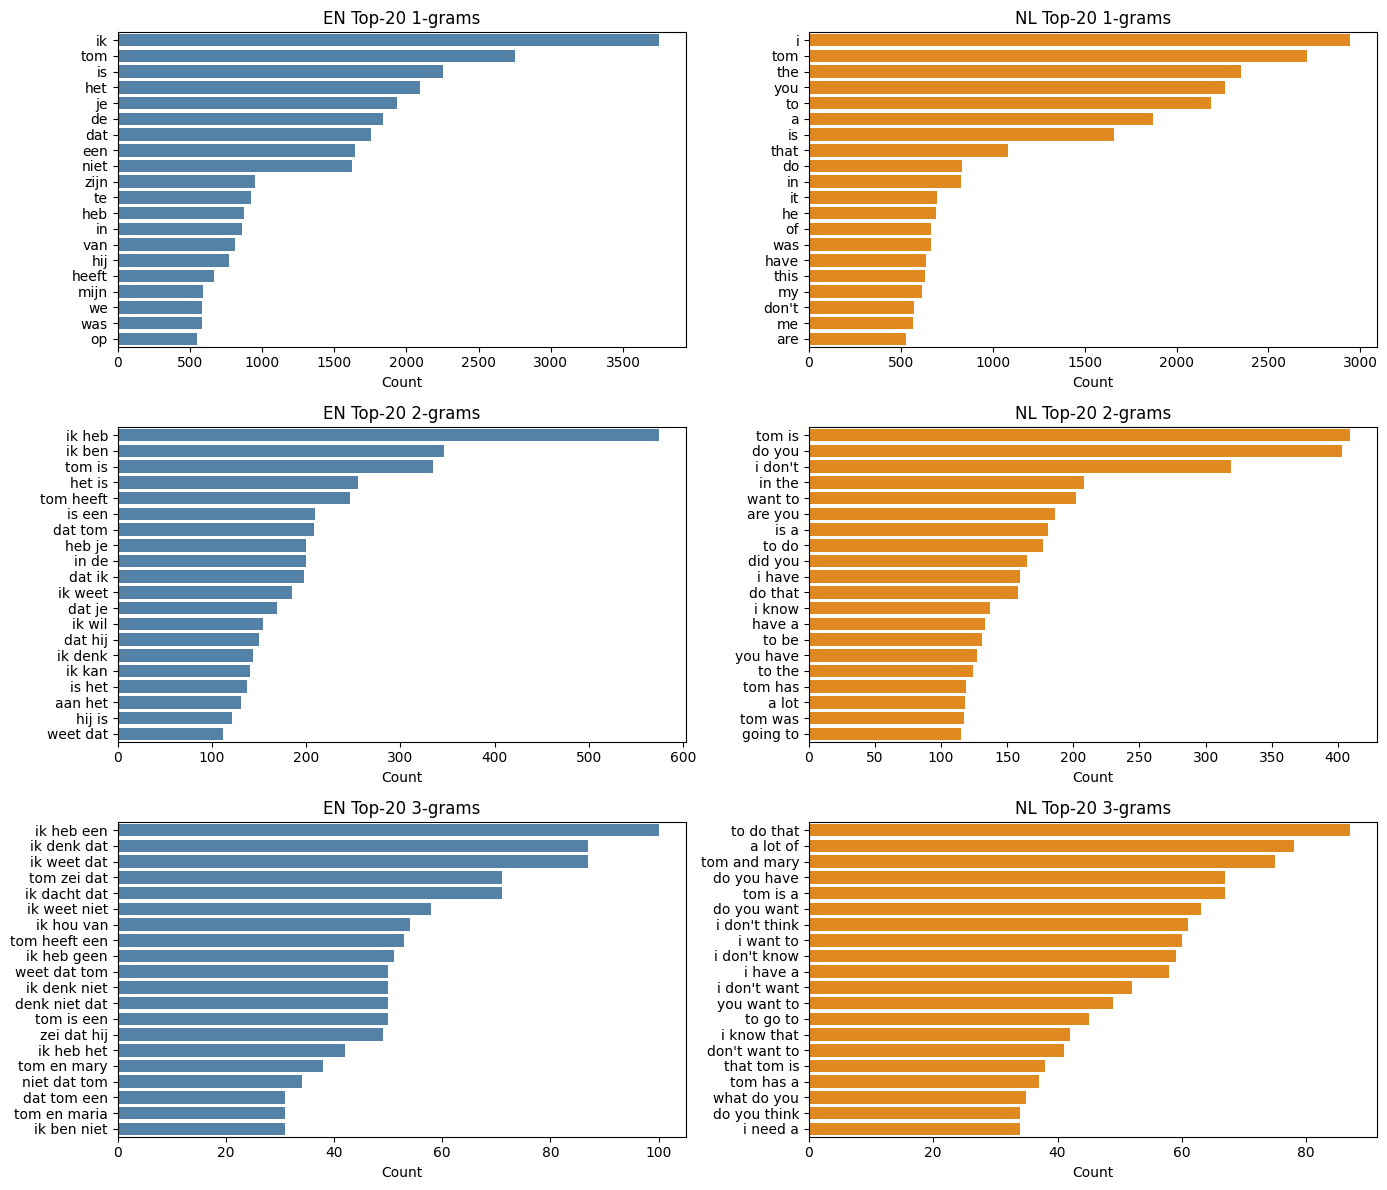

Lexical Diversity (EN) - TTR: 0.0841, MTLD: 110.2288
Lexical Diversity (NL) - TTR: 0.0702, MTLD: 125.7354


In [8]:
# Simple tokenization
def simple_tokenize(text):
    if not isinstance(text, str): return []
    return re.findall(r"[\w']+", text.lower())

# Flatten helper
def flatten(list_of_lists):
    return [item for sub in list_of_lists for item in sub]

# N-grams
def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) if n > 1 else tokens[i] for i in range(len(tokens)-n+1)]

# Collect texts
EN_texts = EN if 'EN' in globals() else []
NL_texts = NL if 'NL' in globals() else []
if not EN_texts and 'en_texts' in globals(): EN_texts = en_texts
if not NL_texts and 'nl_texts' in globals(): NL_texts = nl_texts
if not EN_texts and 'train_pairs' in globals(): EN_texts = [p[1] for p in train_pairs]
if not NL_texts and 'train_pairs' in globals(): NL_texts = [p[0] for p in train_pairs]

# Clean tokens
def ensure_tokens(texts):
    toks = [simple_tokenize(t) for t in texts]
    return [t for t in flatten(toks) if t not in {"start", "end"}]

en_flat = ensure_tokens(EN_texts)
nl_flat = ensure_tokens(NL_texts)

EN_tokens_clean = [[t for t in simple_tokenize(t) if t not in {"start", "end"}] for t in EN_texts]
NL_tokens_clean = [[t for t in simple_tokenize(t) if t not in {"start", "end"}] for t in NL_texts]

# N-gram frequency counts
N_values = [1, 2, 3]
en_ngram_freqs = {N: Counter(flatten([ngrams(t, N) for t in EN_tokens_clean])) for N in N_values}
nl_ngram_freqs = {N: Counter(flatten([ngrams(t, N) for t in NL_tokens_clean])) for N in N_values}

# Plot top n-grams
top_k = 20
fig, axs = plt.subplots(len(N_values), 2, figsize=(14, 4 * len(N_values)))
for idx, N in enumerate(N_values):
    for freqs, labels, ax, color, lang in [
        (en_ngram_freqs[N], 'EN', axs[idx,0], 'steelblue', 'EN'),
        (nl_ngram_freqs[N], 'NL', axs[idx,1], 'darkorange', 'NL')
    ]:
        top = freqs.most_common(top_k)
        if top:
            lbls = [' '.join(t) if isinstance(t, tuple) else t for t,_ in top]
            counts = [c for _,c in top]
            sns.barplot(x=counts, y=lbls, ax=ax, color=color)
            ax.set_title(f'{lang} Top-{top_k} {N}-grams')
            ax.set_xlabel('Count'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

# Lexical diversity using lexical_diversity package
print(f"Lexical Diversity (EN) - TTR: {ld.ttr(en_flat):.4f}, MTLD: {ld.mtld(en_flat):.4f}")
print(f"Lexical Diversity (NL) - TTR: {ld.ttr(nl_flat):.4f}, MTLD: {ld.mtld(nl_flat):.4f}")


EN vocab size: 14,548; NL vocab size (clean): 10,111


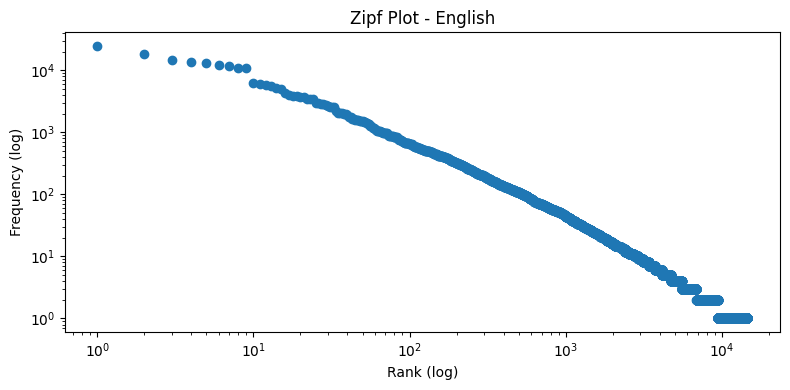

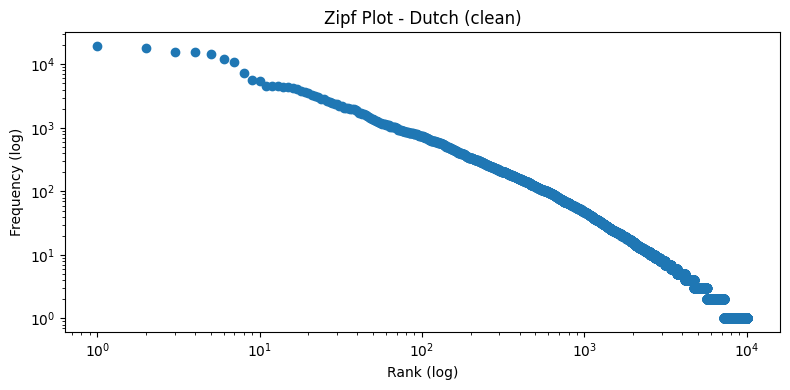

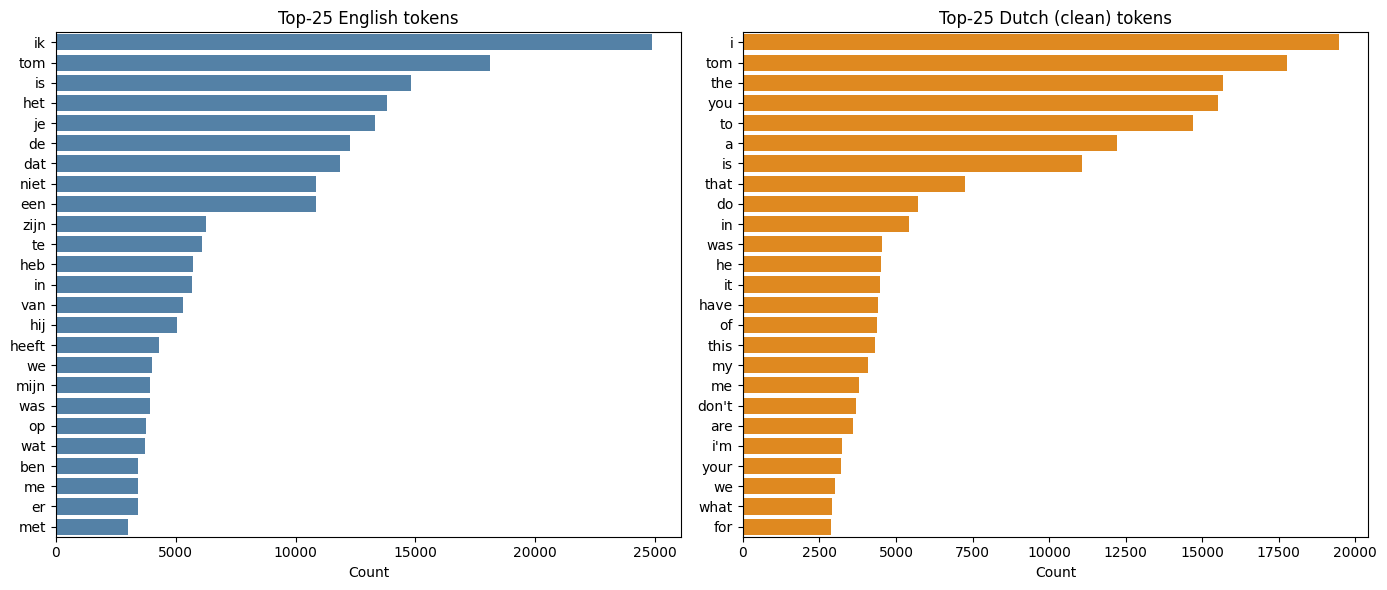

In [9]:
# Collect texts robustly
EN_texts = [t for lst in (globals().get(n) for n in ['EN', 'en_texts']) if lst for t in lst if isinstance(t, str)]
NL_texts = [t for lst in (globals().get(n) for n in ['NL', 'nl_texts']) if lst for t in lst if isinstance(t, str)]

# Fallback to train/val pairs
for pairs_name in ['train_pairs', 'val_pairs']:
    pairs = globals().get(pairs_name)
    if pairs:
        EN_texts.extend(p[1] for p in pairs if isinstance(p[1], str))
        NL_texts.extend(p[0] for p in pairs if isinstance(p[0], str))

# Single-string fallback
for name, lst in [('english', EN_texts), ('dutch', NL_texts)]:
    val = globals().get(name)
    if val and isinstance(val, str) and not lst:
        lst.append(val)

# Tokenize and flatten
en_flat = [t for tok in (simple_tokenize(t) for t in EN_texts) for t in tok if t not in {"start","end"}]
nl_flat = [t for tok in (simple_tokenize(t) for t in NL_texts) for t in tok if t not in {"start","end"}]

en_freq = Counter(en_flat)
nl_freq = Counter(nl_flat)

print(f"EN vocab size: {len(en_freq):,}; NL vocab size (clean): {len(nl_freq):,}")

# Zipf plot
def zipf_plot(freq_counter, title):
    if not freq_counter: freq_counter = Counter()
    freqs = sorted(freq_counter.values(), reverse=True)
    ranks = range(1, len(freqs)+1)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.loglog(ranks, freqs, marker='o', linestyle='none')
    ax.set_title(title)
    ax.set_xlabel('Rank (log)'); ax.set_ylabel('Frequency (log)')
    plt.tight_layout(); plt.show()

zipf_plot(en_freq, 'Zipf Plot - English')
zipf_plot(nl_freq, 'Zipf Plot - Dutch (clean)')

# Top-k tokens
k = 25
fig, axs = plt.subplots(1, 2, figsize=(14,6))
for freq, ax, color, title in [(en_freq, axs[0], 'steelblue', 'English'), (nl_freq, axs[1], 'darkorange', 'Dutch (clean)')]:
    top = freq.most_common(k)
    if top:
        sns.barplot(x=[c for _,c in top], y=[w for w,_ in top], ax=ax, color=color)
    ax.set_title(f'Top-{k} {title} tokens'); ax.set_xlabel('Count'); ax.set_ylabel('')
plt.tight_layout(); plt.show()


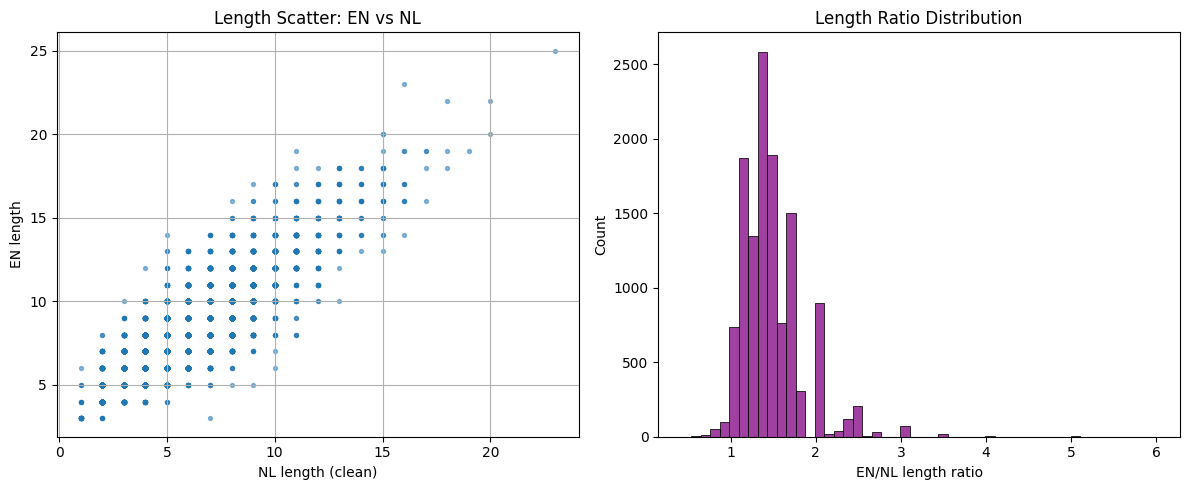

Mean ratio EN/NL: 1.480
Median ratio EN/NL: 1.400
Std ratio EN/NL: 0.358


In [10]:
n = min(len(en_lengths), len(nl_lengths))
en_l = np.array(en_lengths[:n])
nl_l = np.array(nl_lengths[:n])
ratio = en_l / (nl_l + 1e-8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(nl_l, en_l, s=8, alpha=0.5)
plt.xlabel('NL length (clean)')
plt.ylabel('EN length')
plt.title('Length Scatter: EN vs NL')
plt.grid(True)

plt.subplot(1,2,2)
sns.histplot(ratio, bins=50, color='purple')
plt.xlabel('EN/NL length ratio')
plt.title('Length Ratio Distribution')
plt.tight_layout()
plt.show()

print(f"Mean ratio EN/NL: {ratio.mean():.3f}")
print(f"Median ratio EN/NL: {np.median(ratio):.3f}")
print(f"Std ratio EN/NL: {ratio.std():.3f}")

In [15]:
assert "train_pairs" in globals(), "train_pairs must be defined as (EN, NL) pairs."

# Extract and tokenize
en_flat = [t for sent in train_pairs if isinstance(sent[0], str)
           for t in (tok for tok in simple_tokenize(sent[0]) if tok not in {"start", "end"})]
nl_flat = [t for sent in train_pairs if isinstance(sent[1], str)
           for t in (tok for tok in simple_tokenize(sent[1]) if tok not in {"start", "end"})]

en_freq, nl_freq = Counter(en_flat), Counter(nl_flat)

# Hapax legomena
en_hapax = [w for w, c in en_freq.items() if c == 1]
nl_hapax = [w for w, c in nl_freq.items() if c == 1]

# Safeguard against empty vocab to avoid division by zero
en_vocab_size = len(en_freq)
nl_vocab_size = len(nl_freq)

en_hapax_share = (len(en_hapax) / en_vocab_size * 100) if en_vocab_size > 0 else 0.0
nl_hapax_share = (len(nl_hapax) / nl_vocab_size * 100) if nl_vocab_size > 0 else 0.0

print(f"English hapax count: {len(en_hapax):,} ({en_hapax_share:.2f}% of vocab)")
print(f"Dutch hapax count   : {len(nl_hapax):,} ({nl_hapax_share:.2f}% of vocab)")

# Words only in one language
en_only = sorted(set(en_freq) - set(nl_freq))
nl_only = sorted(set(nl_freq) - set(en_freq))

print(f"\nOnly-English vocab items: {len(en_only):,}")
print(f"Only-Dutch   vocab items: {len(nl_only):,}")

sample_k = 25
print("\nSample of English-only words:", en_only[:sample_k])
print("Sample of Dutch-only words  :", nl_only[:sample_k])

# Share of token occurrences that are hapax
en_token_count = len(en_flat)
nl_token_count = len(nl_flat)
share_en_hapax = (sum(1 for t in en_flat if en_freq[t] == 1) / en_token_count * 100) if en_token_count > 0 else 0.0
share_nl_hapax = (sum(1 for t in nl_flat if nl_freq[t] == 1) / nl_token_count * 100) if nl_token_count > 0 else 0.0

print(f"\nShare of token occurrences that are hapax (EN): {share_en_hapax:.2f}%")
print(f"Share of token occurrences that are hapax (NL): {share_nl_hapax:.2f}%")

English hapax count: 3,376 (35.55% of vocab)
Dutch hapax count   : 5,949 (44.24% of vocab)

Only-English vocab items: 8,392
Only-Dutch   vocab items: 12,342

Sample of English-only words: ["'er", '10th', '13th', '14th', '1876', '1950s', '1955', '19th', '1st', '20th', '21st', '25th', '27th', '29th', '30th', '330', '48', '5th', '600', '6th', '8647', '88th', '9th', 'aardvark', 'abandon']
Sample of Dutch-only words  : ["''", "''ben", "''dat", "''echt", "''een", "''er", "''gaat", "''geen", "''gooi", "''heb", "''heeft", "''helemaal", "''het", "''hij", "''hoe", "''hoeveel", "''houd", "''iedereen", "''ik", "''is", "''ja", "''je", "''met", "''nee", "''niets"]

Share of token occurrences that are hapax (EN): 1.00%
Share of token occurrences that are hapax (NL): 1.70%


#### Data pre-processing

In [16]:
vocab_size = 15000
sequence_length = 20

strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", ""
    )

english_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)

dutch_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_english_texts = [pair[0] for pair in train_pairs]
train_dutch_texts   = [pair[1] for pair in train_pairs]

english_tokenizer.adapt(train_english_texts)
dutch_tokenizer.adapt(train_dutch_texts)

In [17]:
batch_size = 64

def format_dataset(eng, dut):
    eng = english_tokenizer(eng)
    dut = dutch_tokenizer(dut)
    features = {
        "english": eng,
        "dutch": dut[:, :-1],  # decoder input, last tokn is skipped
    }
    labels = dut[:, 1:]
    sample_weights = labels != 0
    return features, labels, sample_weights

def make_dataset(pairs):
    eng_texts, dut_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    dut_texts = list(dut_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, dut_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.shuffle(2048).cache().prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_pairs)
val_ds   = make_dataset(val_pairs)

In [18]:
eng_vocab = english_tokenizer.get_vocabulary()
eng_index_lookup = dict(zip(range(len(eng_vocab)), eng_vocab))

dut_vocab = dutch_tokenizer.get_vocabulary()
dut_index_lookup = dict(zip(range(len(dut_vocab)), dut_vocab))

for inputs, targets, rest in train_ds.take(1):
    source_sentence = " ".join(eng_index_lookup[int(i)] for i in inputs['english'][1,])
    target_input_sentence = " ".join(dut_index_lookup[int(i)] for i in inputs['dutch'][1,])
    target_output_sentence = " ".join(dut_index_lookup[int(i)] for i in targets[1,])

print("input  :", source_sentence)
print("target inputs :", target_input_sentence)
print("target outputs:", target_output_sentence)

input  : how long does it take               
target inputs : [start] hoelang duurt dat [end]               
target outputs: hoelang duurt dat [end]                


#### Encoder, Decoder + positonal embedding

In [19]:
class TransformerEncoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.self_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()

    def call(self, source, source_mask):
        residual = x = source
        mask = source_mask[:, None, :]
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = x + residual
        x = self.self_attention_layernorm(x)

        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x


class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.self_attention_layernorm = layers.LayerNormalization()
        self.cross_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.cross_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()

    def call(self, target, source, source_mask):
        residual = x = target
        # Causal self-attention on target side
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = x + residual
        x = self.self_attention_layernorm(x)

        residual = x
        mask = source_mask[:, None, :]
        x = self.cross_attention(
            query=x, key=source, value=source, attention_mask=mask
        )
        x = x + residual
        x = self.cross_attention_layernorm(x)

        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x


class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs):
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [20]:
hidden_dim = 256
intermediate_dim = 2056
num_heads = 8

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)(source)
encoder_output = TransformerEncoder(hidden_dim, intermediate_dim, num_heads)(
    source=x,
    source_mask=source != 0,
)

target = keras.Input(shape=(None,), dtype="int32", name="dutch")
x = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)(target)
x = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(
    target=x,
    source=encoder_output,
    source_mask=source != 0,
)

x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)

transformer = keras.Model([source, target], target_predictions)

#### Compile and train

In [ ]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

# Callback: save best WORD-level model by validation loss
word_best_ckpt = keras.callbacks.ModelCheckpoint(
    filepath="models/transformer_word_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

history = transformer.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[word_best_ckpt],
)
# tussen de 7 en 8 minuten per epoch op laptop met cpu
# tussen de 40 en 50 seconden per epoch op Colab met GPU

# lokaal
transformer.save('models/transformer_versie3.keras')
with open('models/transformer_versie3.hist', 'wb') as file:
    pickle.dump(history.history, file)

Epoch 1/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3481 - loss: 1.6002
Epoch 1: val_loss improved from None to 0.85458, saving model to models/transformer_word_best.keras

Epoch 1: val_loss improved from None to 0.85458, saving model to models/transformer_word_best.keras
918/918 ━━━━━━━━━━━━━━━━━━━━ 84s 90ms/step - accuracy: 0.4549 - loss: 1.2750 - val_accuracy: 0.6028 - val_loss: 0.8546
Epoch 2/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 84s 90ms/step - accuracy: 0.4549 - loss: 1.2750 - val_accuracy: 0.6028 - val_loss: 0.8546
Epoch 2/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6119 - loss: 0.8232
Epoch 2: val_loss improved from 0.85458 to 0.66784, saving model to models/transformer_word_best.keras

Epoch 2: val_loss improved from 0.85458 to 0.66784, saving model to models/transformer_word_best.keras
918/918 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.6335 - loss: 0.7612 - val_accuracy: 0.6721 - val_loss: 0.6678
Epoch 3/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/s

#### Plot train & val curve

In [ ]:
hist = history.history

epochs_range = range(len(hist["loss"]))

plt.figure()
plt.plot(epochs_range, hist["loss"], label="Train loss")
plt.plot(epochs_range, hist["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_range, hist["accuracy"], label="Train accuracy")
plt.plot(epochs_range, hist["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

#### Reload model

In [21]:
# Reload best WORD-level model for evaluation
transformer_recon = keras.models.load_model(
    'models/transformer_word_best.keras',
    custom_objects={
        "PositionalEmbedding": PositionalEmbedding,
        "TransformerEncoder": TransformerEncoder,
        "TransformerDecoder": TransformerDecoder,
    },
)

transformer_recon.summary()

c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dutch (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 256) │  1,319,176 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ dutch[0][0]       │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 256) │  1,582,856 │ transformer_enco… │
│ (TransformerDecode… │                   │            │ not_equal_1[0][0… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, None, 256) │          0 │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None,      │  3,855,000 │ dropout_3[0][0]   │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,341,818 (165.34 MB)

 Trainable params: 14,447,272 (55.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,894,546 (110.22 MB)

## Generate translation

In [22]:
# def decode_sequence(input_sentence):
#     tokenized_input_sentence = english_tokenizer([input_sentence])
#     decoded_sentence = "[start]"
#     for i in range(max_decoded_sentence_length):
#         tokenized_target_sentence = dutch_tokenizer([decoded_sentence])
#         next_token_predictions = transformer_recon.predict(
#             [tokenized_input_sentence, tokenized_target_sentence], verbose=0)
#         sampled_token_index = np.argmax(next_token_predictions[0, i, :])
#         sampled_token = dut_index_lookup[sampled_token_index]
#         decoded_sentence += " " + sampled_token
#         if sampled_token == "[end]":
#             break
#     return decoded_sentence

def generate_translation(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(sequence_length):
        tokenized_target_sentence = dutch_tokenizer([decoded_sentence])
        tokenized_target_sentence = tokenized_target_sentence[:, :-1]
        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = transformer_recon.predict(inputs, verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = dut_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence


#### Qualitative eval uit les notebook

In [23]:
zinnen = ["I heard it through the grapevine",
          "Sitting on the dock of the bay",
          "After laughter comes tears",
          "Do you like good music",
          "Stop, in the name of love",
          "I say a little prayer",
          "Ain't no mountain high enough",
          "you don't have to say you love me"]

m = len(max(zinnen, key=len))

for i in zinnen:
    j = math.ceil((m - len(i)-1)/8)+1
    tab = "".join(np.repeat("\t",j))
    print(i+tab+"-->" + "\t"+generate_translation(i))

I heard it through the grapevine	-->	[start] ik heb het uitgemaakt door de dijk [end]
Sitting on the dock of the bay		-->	[start] zit op de monteur van de kofferbak [end]
After laughter comes tears		-->	[start] na lach komt sneeuwen [end]
Sitting on the dock of the bay		-->	[start] zit op de monteur van de kofferbak [end]
After laughter comes tears		-->	[start] na lach komt sneeuwen [end]
Do you like good music			-->	[start] houden jullie van muziek [end]
Do you like good music			-->	[start] houden jullie van muziek [end]
Stop, in the name of love		-->	[start] stop met de naam van de naam [end]
Stop, in the name of love		-->	[start] stop met de naam van de naam [end]
I say a little prayer			-->	[start] ik zeg iets [end]
I say a little prayer			-->	[start] ik zeg iets [end]
Ain't no mountain high enough		-->	[start] is geen berg genoeg tijd [end]
Ain't no mountain high enough		-->	[start] is geen berg genoeg tijd [end]
you don't have to say you love me	-->	[start] je hoeft niet te zegge

#### Deel 1b
Bespreek de voor- en nadelen van de gebruikte dataset.

[Lexical diversity package](https://pypi.org/project/lexical-diversity/)

> De voordelen en nadelen heb ik opgesteld aan de hand van de informatie van de [datasource](https://www.manythings.org/anki/) waar de meeste limitaties beschreven waren. En de data exploration waar ik gekeken heb naar dingen zoals lengtes en de Type-Token Ratio, Hapax legomena en Measure of Textual Lexical Diversity met behulp van een package. 


#### Voordelen
- De dataset is gratis en toegankelijk en veel gebruikt voor onderwijs en onderzoek
- De Zinnen zijn kort waardoor preprocessing en training makkelijk en snel zijn.
- De Vertalingen zijn door mensen gemaakt en daardoor natuurlijker dan synthetische data
- De zinnen maken gebruik van natuurlijke taal ipv letterlijke vertalingen
- De dataset woordt nogsteeds uitgebreid door community contributions
- De data is gelabeled en heeft markers voor de start en eind positie
- De Zinnen zijn goed uitgelijnd in paren (labelde bron-doel structuur)
- De Engelse en Nederlandse frequenties en n-grams komen sterk overeen volgens de data exploration wat het leren van vertalingen vergemakkelijkt
- De Zipf-distributies voor beide talen zijn bijna identiek wat wijst op vergelijkbare taalstructuur en woordfrequentiepatronen
- De Gemiddelde zinlengte is laag (EN ~6 NL ~7.5) waardoor het model weinig complexiteit hoeft te verwerken.
- Er is een redelijke vocabulair diversiteit volgens de TTR en MTLD metrieken wat betekent dat representaties geleerd kunnen worden.

#### Nadelen dataset
- Vertaalkwaliteit is niet gegarandeert omdat de vertalingen door vrijwilligers gedaan zijn
- Inconsistenties kunnen voorkomen door variatie in bijdragers en stijl.
- De data set kan fouten bevatten volgens de source
- Omdat de dataset gemaakt is met behulp van vrijwilligers kunnen er inconsistentisch zijn in vertalinge
- De betrouwbaarheid van de native speaker status is gebaseerd op vertrouwen
- De nederlandse vocabulair bevat meer unieke woorden dan engels volgens de data exploration wat soms problemen kan veroorzaken bij representaties vinden
- Er zijn vernamelijk korte zinnen met beperkte taal variatie en grammaticale complexiteit
- Sommige zinnen komen uit de oude Tanaka corpus die onnatuurlijk klinkende of ouderwets klikende vertalingen bevat
- Er zijn geen labels voor dingen zoals dialect en onderwerp van de zin waardoor er minder mogelijkheid is voor intrepretatie
- De website zegd niks over de balans van het soort zinnen, er is mogelijk een over representatie van zinnen over specifieke onderwerpen
- Er is mogelijk een bias in zinnen, omdat er meer zinnen zijn met allerdaagse dialogen
- Volgens de hapax zijn er vrij veel zeldzame woorden met beperkte herhaling die mogelijk moeilijk te zijn om goed te leren.

### Samengevat

> De dataset is geschikt voor educatieve toepassingen en een basis-transformer. Door de beperkte variatie, lage zincomplexiteit en veel zeldzame woorden (hapax hoog, TTR/MTLD variatie) is de toepasbaarheid vooral geschikt voor eenvoudige alledaagse vertalingen en minder voor bredere taaltoepassingen.


### Deel 2
We willen dit model nu verbeteren. Bedenk een (mogelijke) verbetering. Het is niet de bedoeling dat je bestaande pretrained modellen gebruikt. Train alles zelf.

#### Deel 2a
Stel een korte lijst van eisen op waar jouw verbeterde model aan hoort te voldoen. 

#### Eisen voor het verbeterde model
- Hogere vertaalnauwkeurigheid dan basismodel (Accuracy en chrF++).
- Lager percentage onbekende woorden (<unk>) en betere dekking van zeldzame woorden.
- Overfitting verminderen ten opzichte van het base model
- Beperkte modelcomplexiteit: geen grote toename van parameters
- Trainings duur niet meer dan verdubbelen meer dan 50% verhogen ten opzichte van base model (omdat het base model trainen al intensief was)

#### Deel 2b
**Uit tevoeren vebering**
> Als enkele iteratie wil ik de tokenization van woordniveau naar subwordniveau veranderen met behulp van [SentencePiece BPE](https://github.com/google/sentencepiece) te gebruiken. In de abstract van [Neural Machine Translation of Rare Words with Subword Units](https://aclanthology.org/P16-1162.pdf) wordt verteld hoe zeldzame worden tijdens het trainen toch geleerd kunnen worden door ze op te breken in de subwords die mogelijk wel te leren zijn uit de data als dit niet mogelij kzou zijn door hele woorden te gebruiken. In sectie [3.2-Language-representation](https://aclanthology.org/P19-1021.pdf) wordt ook benoemd dat BPE geschikt is voor kleinere datasets en wanneer er veel zeldzame worden zijn om toch genoeg te kunnen leren. Zoals benoemd in de conclusie van [Analyzing Cognitive Plausibility of Subword Tokenization](https://aclanthology.org/2023.emnlp-main.272.pdf) is subword tokenization onder andere nuttig voor Nederlands omdat het bij kan dragen aan het leren van woorden met veranderen eindes en stammen. De sequence length zal ik updaten naar de 95e percentiel van de tokenlengte onder BPE-tokenisatie, dit is een standaard hoeveelheid. Dit is nodig omdat subwoordtokenisatie meer tokens per zin genereert dan woordniveau, waardoor langere sequences nodig zijn om truncation te voorkomen.

**Meting van verbetering**
> Ik gebruik chrF++ en percentage onbekende woorden (<unk>) als primaire maatstaven. chrF++ combineert n-gram recall en precision op karakterniveau, waardoor het gevoelig is voor correcte spelling, morfologie en subwordrepresentaties. In [A Survey on Evaluation Metrics for Machine Translation](https://www.mdpi.com/2227-7390/11/4/1006?) wordt het volgende gezegd "BLEU only considers exact word matching and cannot count stems or synonyms", [de documentatie van chRF](https://machinetranslate.org/chrF) zegd zelf ook dat de metriek geschikt is om delen of vormen van woorden te herkenen wat mogelijk is met de BPE. Het bekijken van de % (<unk>) is als sanity check om te kijken of het gebruik van BPE ook echt er voor zorgd dat het model meer zelfzame woorden kan leren of PBE en minder unknown woorden zal hebben.

**Alternatieven en motivatie**

> Andere prestatie maten zoals bijv bleu zijn [volgens Google](https://docs.cloud.google.com/translate/docs/advanced/automl-evaluate)  minder betrouwbaar voor korte zinnen en kleine datasets, of zoals METERO zijn ze minder gevoelig voor morfologische fouten.

> Alternatieve wijzigingen die considered waren ipv als eerst BPE gebruiken waren het toevoegen van regularisatie zoals dropout, word drouput of het model iets simpeler te maken. Dit allemaal om de overfitting te verminderen. Maar uiteindelijk leek eerst overstappen op BPE een betere eerste stap omdat die mogelijk ook al effect op de overfititng zou kunnen hebben en de data engineering logischer leek als eerste stap en daarna het model te tweaken.




#### Extra resources voor eigen leren en inlezen.
- https://aclanthology.o-rg/2022.cl-3.6.pdf
- https://aclanthology.org/2023.cl-4.5.pdf
- https://aclanthology.org/P19-1021.pd

#### Deel 2c
Train dit verbeterde model.

#### Prepare BPE and calculate recommended sequence length

In [24]:
with open(DATA_PATH, encoding="utf-8") as f:
    lines = [l.strip() for l in f if l.strip()]

    
spm.SentencePieceTrainer.train(
    input=DATA_PATH,
    model_prefix="tmp_seq_len",
    vocab_size=15000,
    model_type="bpe",
    character_coverage=0.9995
)

sp_tmp = spm.SentencePieceProcessor(model_file="tmp_seq_len.model")
tok_lens = np.array([len(sp_tmp.encode(l, out_type=int)) for l in lines])

print("mean:", tok_lens.mean())
print("p95:", np.percentile(tok_lens, 95))
print("max:", tok_lens.max())

# int(np.percentile(tok_lens, 95))
sequence_length_bpe = 50 
print("Recommended sequence_length:", sequence_length_bpe)

mean: 39.744705714013165
p95: 50.0
max: 140
Recommended sequence_length: 50


In [25]:
out_dir = Path("sentence_piece")
out_dir.mkdir(exist_ok=True)

vocab_size = 15000

pad_id = 0
unk_id = 1
bos_id = 2
eos_id = 3

tmp_eng = out_dir / "tmp_eng.txt"
tmp_nld = out_dir / "tmp_nld.txt"

with open(tmp_eng, "w", encoding="utf-8") as f:
    f.write("\n".join(train_english_texts))

with open(tmp_nld, "w", encoding="utf-8") as f:
    f.write("\n".join([
        nl.replace("[start]", "").replace("[end]", "").strip() 
        for nl in train_dutch_texts
    ]))

spm.SentencePieceTrainer.train(
    input=str(tmp_eng),
    model_prefix=str(out_dir / "sp_eng"),
    vocab_size=vocab_size,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=pad_id,
    unk_id=unk_id,
    bos_id=bos_id,
    eos_id=eos_id,
)

spm.SentencePieceTrainer.train(
    input=str(tmp_nld),
    model_prefix=str(out_dir / "sp_nld"),
    vocab_size=vocab_size,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=pad_id,
    unk_id=unk_id,
    bos_id=bos_id,
    eos_id=eos_id,
)

sp_eng = spm.SentencePieceProcessor(model_file=str(out_dir / "sp_eng.model"))
sp_nld = spm.SentencePieceProcessor(model_file=str(out_dir / "sp_nld.model"))

print("Trained SPM models saved to", out_dir)


Trained SPM models saved to sentence_piece


In [26]:
train_en = train_english_texts
train_nl = [
    nl.replace("[start]", "").replace("[end]", "").strip()
    for nl in train_dutch_texts
]

val_en = [en for en, nl in val_pairs]
val_nl = [
    nl.replace("[start]", "").replace("[end]", "").strip()
    for en, nl in val_pairs
]

print("Train:", len(train_en), "Val:", len(val_en))


Train: 58706 Val: 12579


In [27]:
def encode_batch_sp(src_texts, tgt_texts, sp_src, sp_tgt, max_len):
    src_ids = []
    tgt_ids = []

    for src, tgt in zip(src_texts, tgt_texts):
        s = sp_src.EncodeAsIds(src)
        t = [bos_id] + sp_tgt.EncodeAsIds(tgt) + [eos_id]

        s = s[:max_len - 1]
        t = t[:max_len]

        s += [pad_id] * (max_len - 1 - len(s))
        t += [pad_id] * (max_len - len(t))

        src_ids.append(s)
        tgt_ids.append(t)

    return np.array(src_ids, np.int32), np.array(tgt_ids, np.int32)

max_len = sequence_length_bpe + 1

X_train, Y_train = encode_batch_sp(train_en, train_nl, sp_eng, sp_nld, max_len)
X_val,   Y_val   = encode_batch_sp(val_en,   val_nl,   sp_eng, sp_nld, max_len)

Y_train_in  = Y_train[:, :-1]
Y_train_out = Y_train[:, 1:]
Y_val_in    = Y_val[:, :-1]
Y_val_out   = Y_val[:, 1:]

print("Encoded shapes:")
print("X_train", X_train.shape, "Y_train", Y_train.shape)
print("X_val", X_val.shape, "Y_val", Y_val.shape)


Encoded shapes:
X_train (58706, 50) Y_train (58706, 51)
X_val (12579, 50) Y_val (12579, 51)


In [28]:
eng_model = out_dir / "english_bpe.model"
nld_model = out_dir / "dutch_bpe.model"

with open(eng_model, "wb") as f:
    f.write(sp_eng.serialized_model_proto())

with open(nld_model, "wb") as f:
    f.write(sp_nld.serialized_model_proto())

print("Saved final SPM models to", out_dir)


Saved final SPM models to sentence_piece


In [29]:
src_vocab_size = sp_eng.GetPieceSize()
tgt_vocab_size = sp_nld.GetPieceSize()

batch_size = 64

Y_train_in  = Y_train[:, :-1]
Y_train_out = Y_train[:, 1:]
Y_val_in    = Y_val[:, :-1]
Y_val_out   = Y_val[:, 1:]

def format_dataset_ids(src_ids, tgt_ids_in, tgt_ids_out):
    features = {
        "english": src_ids,
        "dutch": tgt_ids_in, 
    }
    labels = tgt_ids_out
    sample_weights = labels != 0
    return features, labels, sample_weights

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train_in, Y_train_out))
train_ds = train_ds.batch(batch_size)
train_ds = train_ds.map(format_dataset_ids, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(2048).cache().prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val_in, Y_val_out))
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.map(format_dataset_ids, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

hidden_dim = 256
intermediate_dim = 2056
num_heads = 8

src = keras.Input(shape=(None,), dtype="int32", name="english")
x_src = PositionalEmbedding(sequence_length_bpe, src_vocab_size, hidden_dim)(src)
enc_out = TransformerEncoder(hidden_dim, intermediate_dim, num_heads)(
    source=x_src,
    source_mask=src != 0,
)

tgt = keras.Input(shape=(None,), dtype="int32", name="dutch")
x_tgt = PositionalEmbedding(sequence_length_bpe, tgt_vocab_size, hidden_dim)(tgt)
dec_out = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(
    target=x_tgt,
    source=enc_out,
    source_mask=src != 0,
)

x = layers.Dropout(0.5)(dec_out)
logits = layers.Dense(tgt_vocab_size, activation="softmax")(x)

model = keras.Model(inputs=[src, tgt], outputs=logits)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

bpe_best_ckpt = keras.callbacks.ModelCheckpoint(
    filepath="models/transformer_bpe_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[bpe_best_ckpt],
)

print("Training complete with SentencePiece BPE tokenization, training pipeline matches iteration 1.")

Epoch 1/30
 41/918 ━━━━━━━━━━━━━━━━━━━━ 1:10 80ms/step - accuracy: 0.1971 - loss: 1.2649

KeyboardInterrupt: 

### Train eval

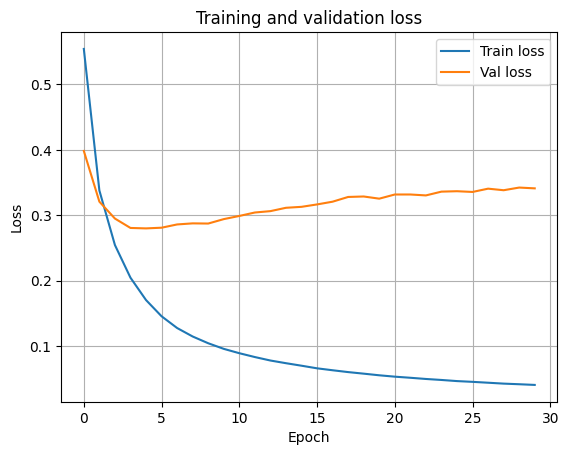

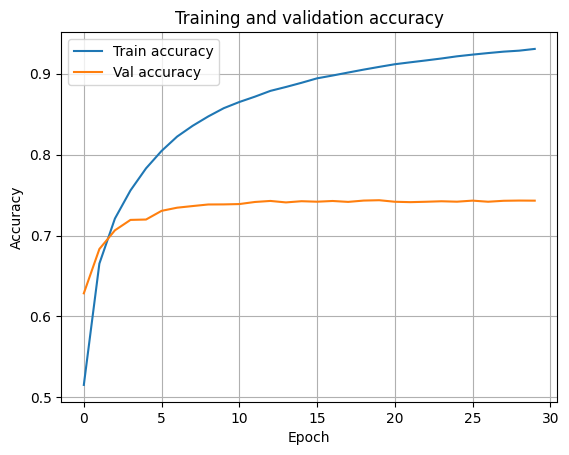

In [ ]:
hist = history.history

epochs_range = range(len(hist["loss"]))

plt.figure()
plt.plot(epochs_range, hist["loss"], label="Train loss")
plt.plot(epochs_range, hist["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_range, hist["accuracy"], label="Train accuracy")
plt.plot(epochs_range, hist["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Reload best BPE model for evaluation
bpe_best_path = "models/transformer_bpe_best.keras"
try:
    bpe_model = keras.models.load_model(
        bpe_best_path,
        custom_objects={
            "PositionalEmbedding": PositionalEmbedding,
            "TransformerEncoder": TransformerEncoder,
            "TransformerDecoder": TransformerDecoder,
        },
    )
    print("Loaded best BPE model from:", bpe_best_path)
except Exception as e:
    print("Warning: could not load best BPE model; using in-memory model. Error:", e)

c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()`

Loaded best BPE model from: models/transformer_bpe_best.keras


## Advanced eval + chrF++

In [31]:
def decode_bpe_iter2(input_sentence: str) -> str:
    # Encode English source with SentencePiece
    src_ids = sp_eng.EncodeAsIds(input_sentence)[:sequence_length_bpe]
    if len(src_ids) < sequence_length_bpe:
        src_ids = src_ids + [0] * (sequence_length_bpe - len(src_ids))  # pad_id = 0
    # Start Dutch decoding with BOS
    decoded_ids = [bos_id]
    for i in range(sequence_length_bpe):
        tgt_in = decoded_ids + [0] * max(0, sequence_length_bpe - len(decoded_ids))
        tgt_in = tgt_in[:sequence_length_bpe]
        # Prepare batch=1 inputs
        x_src = np.array([src_ids], dtype=np.int32)
        x_tgt = np.array([tgt_in], dtype=np.int32)
        # Predict next token distribution at position i
        probs = bpe_model.predict([x_src, x_tgt], verbose=0)
        next_id = int(np.argmax(probs[0, i, :]))
        decoded_ids.append(next_id)
        if next_id == eos_id:
            break
    # Remove BOS and EOS, decode to text
    clean_ids = [tid for tid in decoded_ids if tid not in (bos_id, eos_id, 0)]
    return sp_nld.DecodeIds(clean_ids)

In [43]:
# Config
RUN_FULL = False
MAX_EXAMPLES = 1000
OUT_PATH = Path("outputs/final_eval.json")

# CHRF++ scorer
chrf = CHRF(word_order=2)

STRIP_CHARS = globals().get("strip_chars",
    r"""!"#$%&'()*+,-./:;<=>?@\\^_`{|}~""")
_strip_re = re.compile(f"[{re.escape(STRIP_CHARS)}]")

def normalize_for_eval(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = _strip_re.sub("", s)    
    s = re.sub(r"\s+", " ", s).strip()
    return s

def clean_markers(s: str) -> str:
    if not isinstance(s, str):
        return ""
    return s.replace("[start]", "").replace("[end]", "").strip()

def score_corpus(hyps, refs):
    return float(chrf.corpus_score(hyps, [refs]).score)

def evaluate(pairs, max_examples=None):
    if max_examples:
        pairs = pairs[:max_examples]
    refs_raw = [clean_markers(nl) for _, nl in pairs]
    refs_norm = [normalize_for_eval(r) for r in refs_raw]

    hyps_bpe_raw  = [clean_markers(decode_bpe_iter2(en)) for en, _ in pairs]
    hyps_word_raw = [clean_markers(generate_translation(en)) for en, _ in pairs]
    
    hyps_bpe  = [normalize_for_eval(h) for h in hyps_bpe_raw]
    hyps_word = [normalize_for_eval(h) for h in hyps_word_raw]
    
    score_bpe  = score_corpus(hyps_bpe,  refs_norm)
    score_word = score_corpus(hyps_word, refs_norm)
    
    samples = []
    for i, (en, _) in enumerate(pairs[:10]):
        samples.append({
            "en": en,
            "ref_raw": refs_raw[i],
            "ref_norm": refs_norm[i],
            "word_raw": hyps_word_raw[i],
            "word_norm": hyps_word[i],
            "bpe_raw": hyps_bpe_raw[i],
            "bpe_norm": hyps_bpe[i],
            "len_ref": len(refs_norm[i].split()),
            "len_word": len(hyps_word[i].split()),
            "len_bpe": len(hyps_bpe[i].split())
        })

    return {
        "count": len(pairs),
        "chrFpp_word": score_word,
        "chrFpp_bpe": score_bpe,
        "samples": samples
    }

# choose pairs to evaluate
pairs_eval = test_pairs
results = evaluate(pairs_eval, max_examples=None if RUN_FULL else MAX_EXAMPLES)

# save and print summary
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_PATH, "w", encoding="utf-8") as fh:
    json.dump(results, fh, ensure_ascii=False, indent=2)

print(f"Evaluated {results['count']} examples")
print(f"chrF++ Word: {results['chrFpp_word']:.4f}")
print(f"chrF++ BPE:  {results['chrFpp_bpe']:.4f}")
print(f"Saved results to {OUT_PATH}")
print("\nSample diffs (first 5):")
for s in results["samples"][:5]:
    print("EN:", s["en"])
    print("REF:", s["ref_raw"])
    print("WORD:", s["word_raw"])
    print("BPE:", s["bpe_raw"])
    print("----")


Evaluated 1000 examples
chrF++ Word: 59.3469
chrF++ BPE:  58.5798
Saved results to outputs\final_eval.json

Sample diffs (first 5):
EN: Light the candle.
REF: Steek de kaars aan.
WORD: licht is de kaars
BPE: De kaars heeft de kaars.
----
EN: Let's pretend we're aliens.
REF: Laten we doen alsof we buitenaardse wezens zijn.
WORD: laten we doen alsof we aliens zijn
BPE: Laten we doen alsof we aliens zijn.
----
EN: The soup is too salty.
REF: De soep is te zout.
WORD: de soep is te zout
BPE: De soep is te melk.
----
EN: Tom is singing in French.
REF: Tom zingt in het Frans.
WORD: tom zingt in het frans
BPE: Tom zingt in het Frans.
----
EN: He's afraid of the sea.
REF: Hij is bang van de zee.
WORD: hij is bang voor de zee
BPE: Hij is bang voor zee.
----


        model     chrF++
0  Word-level  59.346933
1         BPE  58.579790


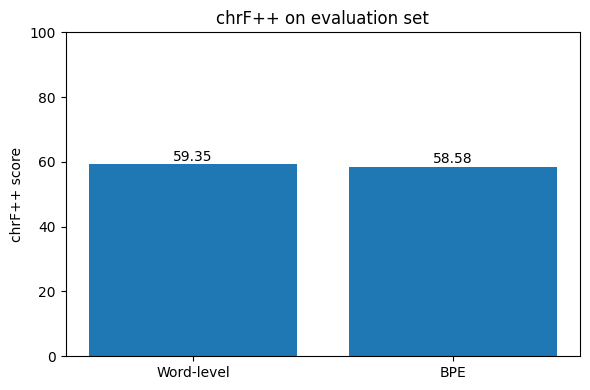

Examples evaluated: 1000
chrF++ Word: 59.3469
chrF++ BPE:  58.5798
Delta (BPE - Word) = -0.7671


,en,ref_len,word_len,bpe_len
0,Light the candle.,4,4,5
1,Let's pretend we're aliens.,8,7,7
2,The soup is too salty.,5,5,5
3,Tom is singing in French.,5,5,5
4,He's afraid of the sea.,6,6,5
5,How silly of me!,4,4,4
6,He was too drunk to drive home.,9,9,9
7,I threw away my shoes.,5,5,5
8,Who are you angry with?,5,4,5
9,This is dangerous.,3,3,3


In [60]:
# load results produced by the evaluation cell
json_path = Path('outputs/final_eval.json')
with open(json_path, 'r', encoding='utf-8') as f:
    res = json.load(f)

# normalize keys from the evaluator
word_score = res.get('chrFpp_word', res.get('score_word_chrFpp'))
bpe_score  = res.get('chrFpp_bpe',  res.get('score_bpe_chrFpp'))
count = res.get('count', None)
samples = res.get('samples', [])

# summary dataframe
df = pd.DataFrame({
    'model': ['Word-level', 'BPE'],
    'chrF++': [word_score, bpe_score]
})
print(df)

# simple bar chart comparison
plt.figure(figsize=(6,4))
plt.bar(df['model'], df['chrF++'])
plt.title('chrF++ on evaluation set')
plt.ylabel('chrF++ score')
plt.ylim(0, 100)
for i, v in enumerate(df['chrF++']):
    plt.text(i, v + 1, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

# show delta and count
delta = bpe_score - word_score
print(f"Examples evaluated: {count}")
print(f"chrF++ Word: {word_score:.4f}")
print(f"chrF++ BPE:  {bpe_score:.4f}")
print(f"Delta (BPE - Word) = {delta:.4f}")

# detailed diagnostics from samples
if samples:
    # build a diagnostics table for the samples
    diag_rows = []
    for s in samples:
        diag_rows.append({
            'en': s.get('en'),
            'ref_len': s.get('len_ref'),
            'word_len': s.get('len_word'),
            'bpe_len': s.get('len_bpe')
        })
    diag_df = pd.DataFrame(diag_rows)
    # show the first few rows as an interactive table in notebook
    display(diag_df.head(10))

    # histogram of length differences
    len_diff_word = diag_df['word_len'] - diag_df['ref_len']
    len_diff_bpe  = diag_df['bpe_len']  - diag_df['ref_len']



In [62]:
# Unknown token analysis: whole-word vs BPE (normalized, consistent, and verified)
import re

# Helper: percentage safely
pct = lambda unknown, total: (unknown / total * 100.0) if total else 0.0

# Ensure vocab containers are sets for fast membership
eng_vocab_set = eng_vocab if isinstance(eng_vocab, set) else set(eng_vocab)
nld_vocab_set = nld_vocab if isinstance(nld_vocab, set) else set(nld_vocab)

# Strip special markers for BPE (if present in inputs)
def strip_markers(s: str) -> str:
    return s.replace("[start]", "").replace("[end]", "").strip()

# Normalize whole-word tokens: lowercase and keep alphanumeric chunks
word_unknown_en = 0; word_total_en = 0
word_unknown_nl = 0; word_total_nl = 0

for sent in train_english_texts:
    toks = re.findall(r"\w+", strip_markers(sent).lower())
    word_total_en += len(toks)
    word_unknown_en += sum(1 for t in toks if t not in eng_vocab_set)

for sent in train_dutch_texts:
    toks = re.findall(r"\w+", strip_markers(sent).lower())
    word_total_nl += len(toks)
    word_unknown_nl += sum(1 for t in toks if t not in nld_vocab_set)

word_eng_pct = pct(word_unknown_en, word_total_en)
word_nld_pct = pct(word_unknown_nl, word_total_nl)

# Sentence-level unknown presence (whole-word)
word_sent_unknown_en = sum(1 for sent in train_english_texts 
                           if any(t not in eng_vocab_set for t in re.findall(r"\w+", strip_markers(sent).lower())))
word_sent_unknown_nl = sum(1 for sent in train_dutch_texts 
                           if any(t not in nld_vocab_set for t in re.findall(r"\w+", strip_markers(sent).lower())))

# BPE unknowns
# Read unknown ids directly from the processors and verify they map to '<unk>'
eng_sp_unk_id = sp_eng.unk_id()
nld_sp_unk_id = sp_nld.unk_id()
eng_sp_unk_tok = sp_eng.id_to_piece(eng_sp_unk_id)
nld_sp_unk_tok = sp_nld.id_to_piece(nld_sp_unk_id)
assert eng_sp_unk_tok == "<unk>", f"Unexpected EN unk tok: {eng_sp_unk_tok}"
assert nld_sp_unk_tok == "<unk>", f"Unexpected NL unk tok: {nld_sp_unk_tok}"

# If BOS/EOS or PAD are added elsewhere, exclude them
special_ids = {pad_id, bos_id, eos_id} if 'pad_id' in globals() and 'bos_id' in globals() and 'eos_id' in globals() else set()

bpe_unknown_en = 0; bpe_total_en = 0
bpe_unknown_nl = 0; bpe_total_nl = 0

for sent in train_english_texts:
    ids = sp_eng.encode(strip_markers(sent), out_type=int)
    # Exclude special ids from totals if present
    filtered = [i for i in ids if i not in special_ids]
    bpe_total_en += len(filtered)
    bpe_unknown_en += sum(1 for i in filtered if i == eng_sp_unk_id)

for sent in train_dutch_texts:
    ids = sp_nld.encode(strip_markers(sent), out_type=int)
    filtered = [i for i in ids if i not in special_ids]
    bpe_total_nl += len(filtered)
    bpe_unknown_nl += sum(1 for i in filtered if i == nld_sp_unk_id)

bpe_eng_pct = pct(bpe_unknown_en, bpe_total_en)
bpe_nld_pct = pct(bpe_unknown_nl, bpe_total_nl)

# Sentence-level unknown presence (BPE)
bpe_sent_unknown_en = sum(1 for sent in train_english_texts 
                          if any(i == eng_sp_unk_id for i in sp_eng.encode(strip_markers(sent), out_type=int)))
bpe_sent_unknown_nl = sum(1 for sent in train_dutch_texts 
                          if any(i == nld_sp_unk_id for i in sp_nld.encode(strip_markers(sent), out_type=int)))

print(f"Whole-word EN unknowns: {word_unknown_en}/{word_total_en} ({word_eng_pct:.4f}%)")
print(f"Whole-word NL unknowns: {word_unknown_nl}/{word_total_nl} ({word_nld_pct:.4f}%)")
print(f"Whole-word EN sentences with unknowns: {word_sent_unknown_en}/{len(train_english_texts)}")
print(f"Whole-word NL sentences with unknowns: {word_sent_unknown_nl}/{len(train_dutch_texts)}")
print(f"BPE EN unknowns:        {bpe_unknown_en}/{bpe_total_en} ({bpe_eng_pct:.4f}%)")
print(f"BPE NL unknowns:        {bpe_unknown_nl}/{bpe_total_nl} ({bpe_nld_pct:.4f}%)")
print(f"BPE EN sentences with <unk>: {bpe_sent_unknown_en}/{len(train_english_texts)}")
print(f"BPE NL sentences with <unk>: {bpe_sent_unknown_nl}/{len(train_dutch_texts)}")

Whole-word EN unknowns: 24893/355352 (7.0052%)
Whole-word NL unknowns: 306/350959 (0.0872%)
Whole-word EN sentences with unknowns: 17490/58706
Whole-word NL sentences with unknowns: 256/58706
BPE EN unknowns:        672/438726 (0.1532%)
BPE NL unknowns:        652/422765 (0.1542%)
BPE EN sentences with <unk>: 630/58706
BPE NL sentences with <unk>: 566/58706


#### Deel 3b
Bespreek het volgende.
- Hoeveel je model verbeterd (of verslechterd) is
- In het geval van geen verbetering, een mogelijke verklaring waarom het niet werkte.
- Licht toe wat je volgende stap zou zijn om betere resultaten te halen. Deze stap hoef je niet uit te voeren, maar wees wel specifiek en verantwoord het met jouw resultaten.

Houd je antwoorden kort en bondig.

**Resultaten en requirements**
> De overstap naar BPE verbeterde de woorddekking sterk (<unk> daalde in het Engels van ~7% naar ~0.15% en in het Nederlands bleef het rond ~0.15%). Ook het aantal zinnen met <unk> nam sterk af. Ondanks deze duidelijke verbetering in dekking bleef de kwaliteit achter: zowel accuracy als chrF++ bleven lager dan bij het per woord getokenizde model. Het model bleef even complex en de trainingstijd steeg slechts 25%, dus die requirements zijn gehaald. De belangrijkste tekortkoming is dat het model niet beter bestand is tegen overfitting; het overfitte zelfs sneller dan het basemodel. Daarmee is de belangrijkste vereiste niet behaald, ook al is de woorddekking inhoudelijk sterk verbeterd.

**Vervolgstappen**
> De logische volgende stap is het toevoegen van regularisatie, te beginnen met standaardmethoden zoals dropout of word dropout. Als verdere optie sluit het gebruiken van BFE-dropout zoals beschreven in de abstract van [BPE-Dropout: Simple and Effective Subword Regularization](https://aclanthology.org/2020.acl-main.170.pdf) goed aan op mijn gemaakte keuze en zou dit helpen om het model stabieler en minder overfit-gevoelig te maken. Daarnaast kan het waardevol zijn om een extra metriek toe te voegen, zoals BLEU of perplexity, zodat ik de twee modelen beter kan beoordelen op hun eigen sterktes.